# Questão 1

In [1]:
from examples.seismic.source import RickerSource, TimeAxis
from examples.seismic import setup_geometry, PointSource, Receiver, plot_velocity
from examples.seismic import SeismicModel, AcquisitionGeometry
try:
    from examples.seismic.stiffness.model import ElasticModel
except:
    from examples.seismic.stiffness.model import ISOSeismicModel as ElasticModel
    
from examples.seismic.stiffness.utils import C_Matrix, D, S, vec
from devito import *
from examples.seismic.stiffness import iso_elastic_setup
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from mpl_toolkits.axes_grid1 import make_axes_locatable
from devito import configuration, norm
from IPython.display import display, display_html, HTML

configuration['log-level'] = 'WARNING'

%matplotlib inline

mpi4py is not available. You must install it


# Preparação do ambiente

## Parâmetros dos operadores de diferenças finitas

In [2]:
space_order=8
time_order=2

## Definição do modelo

### Dimensões do modelo

Como a fonte possui uma frequência máxima de $45$ $\mathrm{Hz}$, a ordem das derivadas espaciais é $8$ ($F=4$) e a velocidade mínima de propagação é $1500$ $\mathrm{m/s}$, o espaçamento máximo obedecerá

$$
\begin{aligned}
    \max(\Delta x, \Delta z) &\le \frac{\min(v_P, v_S)}{F f_{\max}}\\
        &= \frac{1500\ \mathrm{m/s}}{4 \times 45\ \mathrm{Hz}}\\
        &= 8 + \frac{1}{3}
\end{aligned}
$$

<!-- , a frequência de pico de uma fonte Ricker será aproximadamente $15$ $\mathrm{Hz}$. -->

Com base nisto, foi escolhido um espaçamento de $\Delta x = \Delta z = 8\ \mathrm{m}$. Visto que o modelo possui dimensões $w \times h = 2000\ \mathrm{m} \times 2000\ \mathrm{m}$, a malha terá
$$
n_x = \frac{w}{\Delta x} + 1 = \frac{2000\ \mathrm{m}}{8\ \mathrm{m}} + 1 = 251
$$
pontos ao longo do eixo x, e
$$
n_z = \frac{h}{\Delta z} + 1 = \frac{2000\ \mathrm{m}}{8\ \mathrm{m}} + 1 = 251
$$
pontos ao longo do eixo z.

In [3]:
shape = (251, 251)
spacing = (8, 8)
origin = (0., 0.)
nbl=50

### Parâmetros físicos

O modelo possui duas camada cujas propriedades físicas são

Camada | $v_P$ ($\mathrm{km/s}$) | $v_S$ ($\mathrm{km/s}$)
-|-|-
1|1.5|0.0
2|3.0|2.0

In [4]:
vp1 = 1.5
vs1 = 0

vp2 = 3
vs2 = 2


vp = vp1 * np.ones(shape, dtype=np.float32)
vp[:,shape[1]//2:] = vp2
vs = vs1 * np.ones(shape, dtype=np.float32)
vs[:,shape[1]//2:] = vs2

# rho = 2 * np.ones(shape, dtype=np.float32)
# rho[:,shape[1]//2:] = 3

In [5]:
# model = ElasticModel(vp=vp, vs=vs, b=1/rho, origin=origin, shape=shape, spacing=spacing,
#               space_order=space_order, nbl=nbl, bcs="damp")
model = ElasticModel(vp=vp, vs=vs, origin=origin, shape=shape, spacing=spacing,
              space_order=space_order, nbl=nbl, bcs="damp")

In [6]:
def plot_model(model, source=None, receiver=None, colorbar=True, cmap="jet"):
    """
    Esta função exibe os perfis de velocidade da onda P e densidade.
    """
    domain_size = 1.e-3 * np.array(model.domain_size)
    origin = 1.e-3 * np.array(model.origin)
    extent = [origin[0], origin[0] + domain_size[0],
              origin[1] + domain_size[1], origin[1]]

    slices = tuple(slice(model.nbl, -model.nbl) for _ in range(2))

    fig, axes = plt.subplots(1,2, figsize=(14,5))
    ax_vp = axes[0]
    ax_vs = axes[1]
    # ax_rho = axes[2]
    
    vp = model.vp.data[slices]
    vs = model.vs.data[slices]

    plot_vp = ax_vp.imshow(np.transpose(vp), animated=True, cmap='jet',
                      vmin=np.min(vp), vmax=np.max(vp),
                      extent=extent)
    ax_vp.set_xlabel('X position (km)')
    ax_vp.set_ylabel('Depth (km)')
    

    plot_vs = ax_vs.imshow(np.transpose(vs), animated=True, cmap='magma',
                      vmin=np.min(vs), vmax=np.max(vs),
                      extent=extent)
    ax_vs.set_xlabel('X position (km)')

    for ax in axes:
        # Plot source points, if provided
        if receiver is not None:
            ax.scatter(1e-3*receiver[:, 0], 1e-3*receiver[:, 1],
                        s=25, c='green', marker='D')

        # Plot receiver points, if provided
        if source is not None:
            ax.scatter(1e-3*source[:, 0], 1e-3*source[:, 1],
                        s=25, c='red', marker='o')
        
        # Ensure axis limits
        ax.set_xlim(origin[0], origin[0] + domain_size[0])
        ax.set_ylim(origin[1] + domain_size[1], origin[1])


    # Create aligned colorbar on the right
    if colorbar:
        divider = make_axes_locatable(ax_vp)
        cax = divider.append_axes("right", size="5%", pad=0.05)
        cbar = plt.colorbar(plot_vp, cax=cax)
        cbar.set_label('P Velocity (km/s)')
        
        divider = make_axes_locatable(ax_vs)
        cax = divider.append_axes("right", size="5%", pad=0.05)
        cbar = plt.colorbar(plot_vs, cax=cax)
        cbar.set_label('S Velocity (km/s)')

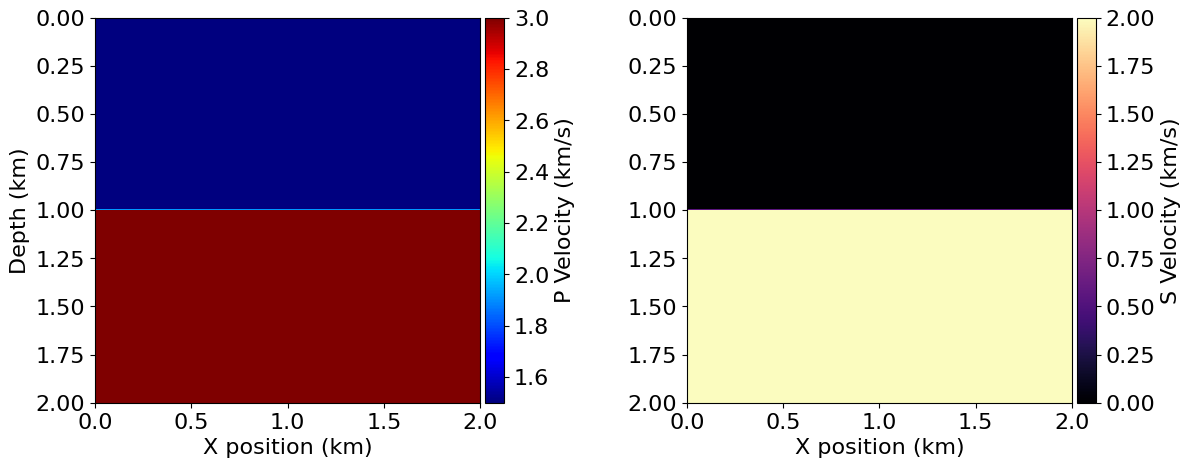

In [7]:
plot_model(model)

## Parâmetros da aquisição

### Tempo de aquisição

O período de aquisição inicia em $t_0 = 0$ $\mathrm{ms}$ e termina em $t_n = 700$ $\mathrm{ms}$. 

O comprimento do passo temporal, $\Delta t$, foi escolhido a partir da condição de estabilidade:
$$
\begin{aligned}
    \Delta t &\le \frac{1}{\max(v_P, v_S)\sqrt{\dfrac{1}{\Delta x^2} + \dfrac{1}{\Delta z^2}}}\\
        &= \frac{1}{3000\ \mathrm{m/s} \sqrt{\dfrac{1}{(8\ \mathrm{m})^2} + \dfrac{1}{(8\ \mathrm{m})^2}}}\\
        &\approx 1.8856\ \mathrm{ms}
\end{aligned}
$$
Com base nisto, o comprimento do passo temporal escolhido foi $\Delta t = 1.5\ \mathrm{ms}$.

In [8]:
t0 = 0.  # ms
tn = 700. # ms
dt = 1.4

time_range = TimeAxis(start=t0, stop=tn, step=dt)

### Geometria

Será utilizada uma fonte Ricker, que é parametrizada com uma frequência de pico $f_0 \approx \dfrac{f_{\max}}{3} = 15\ \mathrm{Hz}$.

In [9]:
# Frequência de pico da fonte
f0 = 0.015

In [10]:
zero_coords = np.array([[0,0]], dtype=model.dtype) # Para zerar as coordenadas da fonte e dos receptores da geometria.
geometry = AcquisitionGeometry(model, zero_coords, zero_coords, t0, tn)
geometry.resample(dt)

In [11]:
src = RickerSource(name='src', grid=model.grid, f0=f0,
                   npoint=1, time_range=time_range)

# Posicionamento da fonte
src.coordinates.data[0, 0] = 1.0 * 1e3 # x = 1 km
src.coordinates.data[0, 1] = 0.7 * 1e3 # z = 0.7 km

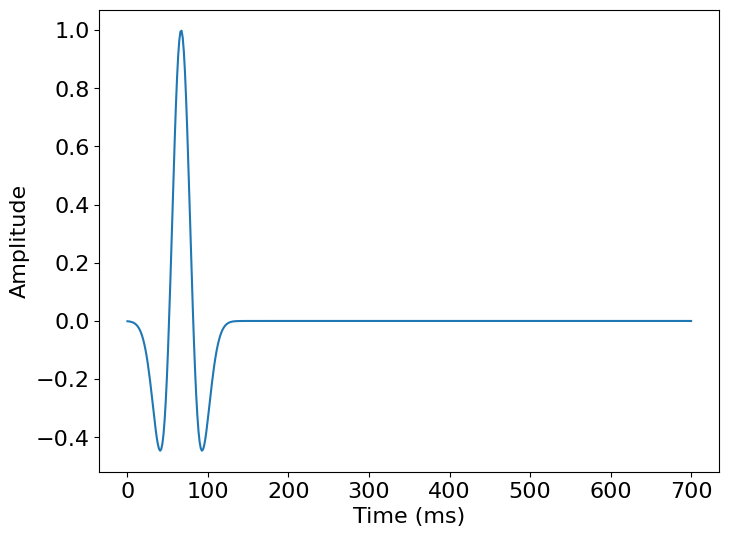

In [12]:
src.show() # Assinatura da fonte

Como apenas a pressão será registrada, basta criar um único receptor para ler o campo $\tau_{xx}$ ou $\tau_{zz}$, pois, para em um regime de pressão hidroestática, $\tau_{xx} = \tau_{zz} = -P$. Neste caso, foi escolhido o campo $\tau_{xx}$.

#### Posição da fonte

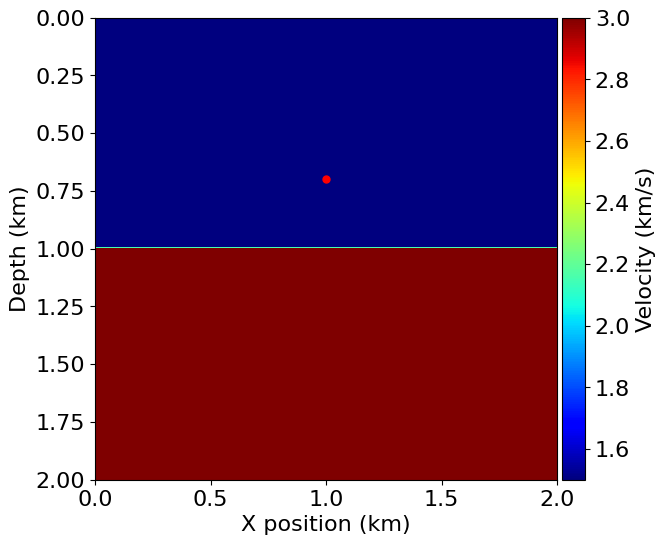

In [13]:
plot_velocity(model, source=src.coordinates.data)

### Definição da equação da onda elástica de 1ª ordem

Aqui é definida no *Devito* o sistema de equações

$$
\begin{cases}
    \dfrac{\partial \mathbf{\tau}}{\partial t} - CD^T\mathbf{v} = \mathbf{S}\\
    \dfrac{\partial \mathbf{v}}{\partial t} - D\mathbf{\tau} = 0
\end{cases}
$$

que é a formulação de propagação da onda elástica de 1ª ordem com densidade constante, em que:

- $\mathbf{\tau}$ é o tensor de estresses;
- $\mathbf{v}$ é o campo de velocidade de partícula;
- $C$ é a matriz de rigidez:

    $$
    C = \begin{bmatrix}
        \lambda + 2\mu & \lambda        & \lambda        & 0 & 0 & 0\\
            \lambda        & \lambda + 2\mu & \lambda        & 0 & 0 & 0\\
            \lambda        & \lambda        & \lambda + 2\mu & 0 & 0 & 0\\
            0 & 0 & 0 & \mu & 0 & 0\\
            0 & 0 & 0 & 0 & \mu & 0\\
            0 & 0 & 0 & 0 & 0 & \mu
    \end{bmatrix}
    $$

- $D$ é a matriz de derivadas espaciais:

    $$
    D = \begin{bmatrix}
        \partial_x & 0 & 0 & 0 & \partial_z & \partial_y\\
        0 & \partial_{y} & 0 & \partial_{z} & 0 & \partial_{x}\\
        0 & 0 & \partial_{z} & \partial_{y} & \partial_{x} & 0
    \end{bmatrix}
    $$
    
- $\mathbf{S}$ é o termo fonte;

In [14]:
C = C_Matrix(model,'vp-vs-rho')

In [15]:
tau = vec(TensorTimeFunction(name='tau', grid=model.grid, time_order=time_order, space_order=space_order, save=geometry.nt))
v = VectorTimeFunction(name='v', grid=model.grid, time_order=time_order, space_order=space_order, save=geometry.nt)

In [16]:
# Sistemas de equações da onda elástica de 1ª ordem
EDP_tau = tau.dt - C* S(v.forward)
EDP_v = v.dt - D(tau)

In [17]:
# Expressão para o campo de ondas futuro, P(x, t + dt)
stencil_tau = Eq(tau.forward, solve(EDP_tau, tau.forward))
stencil_v = Eq(v.forward, solve(EDP_v, v.forward))
stencil_tau

Eq(Matrix([[tau_xx(time + dt, x, y)], [tau_yy(time + dt, x, y)], [tau_xy(time + dt, x + h_x/2, y + h_y/2)]]), Matrix([[dt*(rho*vp(x, y)**2*Derivative(v_x(time + dt, x + h_x/2, y), x) + (rho*vp(x, y)**2 - 2*rho*vs(x, y)**2)*Derivative(v_y(time + dt, x, y + h_y/2), y) + tau_xx(time, x, y)/dt)], [dt*(rho*vp(x, y)**2*Derivative(v_y(time + dt, x, y + h_y/2), y) + (rho*vp(x, y)**2 - 2*rho*vs(x, y)**2)*Derivative(v_x(time + dt, x + h_x/2, y), x) + tau_yy(time, x, y)/dt)], [dt*(rho*(Derivative(v_x(time + dt, x + h_x/2, y), y) + Derivative(v_y(time + dt, x, y + h_y/2), x))*vs(x, y)**2 + tau_xy(time, x + h_x/2, y + h_y/2)/dt)]]))

Com base na expressão acima para o campo $\tau(\mathbf{x}, t + \Delta t)$, observa-se que o termo fonte possui um coeficiente igual a $\Delta t$. Logo, a fonte $S$ deve ser injetada no campo de ondas futuro como $\Delta t S(\mathbf{x}, t)$. Como é uma fonte de pressão, apenas os campos $\tau_{xx}$ e $\tau_{zz}$ serão perturbados.

In [18]:
# Símbolo do espaçamento temporal
s = model.grid.stepping_dim.spacing

# Expressão do termo fonte a ser injetada no stencil criado acima
src_term_xx = src.inject(tau[0].forward, expr = s * src)
src_term_zz = src.inject(tau[1].forward, expr = s * src)

src_term = src_term_xx + src_term_zz

### Criação do operador de diferenças finitas

In [19]:
# Criação do operador do Devito
op = Operator([stencil_v, stencil_tau] + src_term, subs=model.spacing_map)

# Resolução da alternativa a) Interface fluido-sólido

## I. Modelagem e plotagem

### Modelagem

In [20]:
# Execução
op(dt=dt)

PerformanceSummary([(PerfKey(name='section0', rank=None),
                     PerfEntry(time=0.15877100000000022, gflopss=0.0, gpointss=0.0, oi=0.0, ops=0, itershapes=[])),
                    (PerfKey(name='section1', rank=None),
                     PerfEntry(time=4.899999999999996e-05, gflopss=0.0, gpointss=0.0, oi=0.0, ops=0, itershapes=[]))])

### Plotagem do campo de ondas

In [21]:
def plot_wavefield(u, geometry, src_pos, model, title=None, t0=0, tn=-1, rec_pos=None, annotation_callback=None):
    """
    Exibe o campo de onda em 4 instantes distribuídos em um período determinado por `t0` e `tn`
    """
    shape_pad = np.array(model.shape)
    origin_pad = origin
    extent_pad = tuple([s*(n-1) for s, n in zip(spacing, shape_pad)])

    # Note: flip direction of second dimension to make the plot positive downwards
    plt_extent = [origin_pad[0], origin_pad[0] + extent_pad[0],
                origin_pad[1] + extent_pad[1], origin_pad[1]]
    
    fig, axes = plt.subplots(1, 4, figsize=(20, 4), sharex=True)
    fig.suptitle(title, size=20, y=1.05)
    isfirst = True
    last_ax = None
    last_plot = None

    t0 = t0 - geometry.t0
    tn = tn - geometry.t0

    snapshots = None
    if tn < 0:
        idx_min = max(int(np.round(t0/dt)), 0)
        snapshots = np.linspace(idx_min, geometry.nt - 1, num=4, dtype=np.int32)
    else:
        idx_min = max(int(np.round(t0/dt)), 0)
        idx_max = min(int(np.round(tn/dt)), geometry.nt - 1)
        snapshots = np.linspace(idx_min, idx_max, num=4, dtype=np.int32)


    udata = u.data
    amax = np.max(np.abs(udata[geometry.nt-1, :, :]))

    for count, ax in enumerate(axes.ravel()):
        snapshot = snapshots[count]
        last_plot = ax.imshow(udata[snapshot, model.nbl:-model.nbl, model.nbl:-model.nbl].T,
                              cmap="seismic", vmin=-amax,
                  vmax=+amax, extent=plt_extent)
        ax.plot(src_pos[0], src_pos[1], 'red', linestyle='None', marker='*',
                markersize=8, label="Source")
        
        ax.plot([model.origin[0], model.domain_size[0]],
                [model.domain_size[1]/2, model.domain_size[1]/2], ls='dashed', color='orange')

        if type(rec_pos) != type(None):
            ax.plot(rec_pos[0], rec_pos[1], 'green', linestyle='None', marker='v',
                    markersize=8, label="Receiver")

        domain_size = np.array(model.domain_size)
            
        ax.grid()
        ax.tick_params('both', length=4, width=0.5, which='major', labelsize=11)

        ax.set_title("t=%.2fms" % (snapshot*dt + geometry.t0), fontsize=12)
        ax.set_xlabel("x (m)", fontsize=12)
        isfirst and ax.set_ylabel("z (m)", fontsize=12)
        isfirst = False
        last_ax = ax

    divider = make_axes_locatable(last_ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    plt.colorbar(last_plot, cax=cax)

    if annotation_callback:
        annotation_callback(fig, axes)

In [22]:
def annotation_callback_a_1(fig, axes):
    snap200 = axes[0]
    snap366 = axes[1]
    snap533 = axes[2]
    snap700 = axes[3]

    arrowprops={'width': 5}

    snap200.annotate('Incidente P', (800, 850), (250,1500), arrowprops=arrowprops)
    
    snap533.annotate('Transmitida P', (1000, 1800), (500,1000), arrowprops=arrowprops)
    snap533.annotate('Refratada P', (200, 900), (0,250), arrowprops=arrowprops)

    snap700.annotate('Refletida P', (1300, 500), (500,1000), arrowprops=arrowprops)
    snap700.annotate('Transmitida S', (1550, 1700), (500,1300), arrowprops=arrowprops)
    

def annotation_callback_a_2(fig, axes):
    snap200 = axes[0]
    snap366 = axes[1]
    snap533 = axes[2]
    snap700 = axes[3]

    arrowprops={'width': 5}

    snap533.annotate('Transmitida P', (1000, 1800), (500,1000), arrowprops=arrowprops)

    snap700.annotate('Transmitida S', (1550, 1700), (500,1300), arrowprops=arrowprops)
    

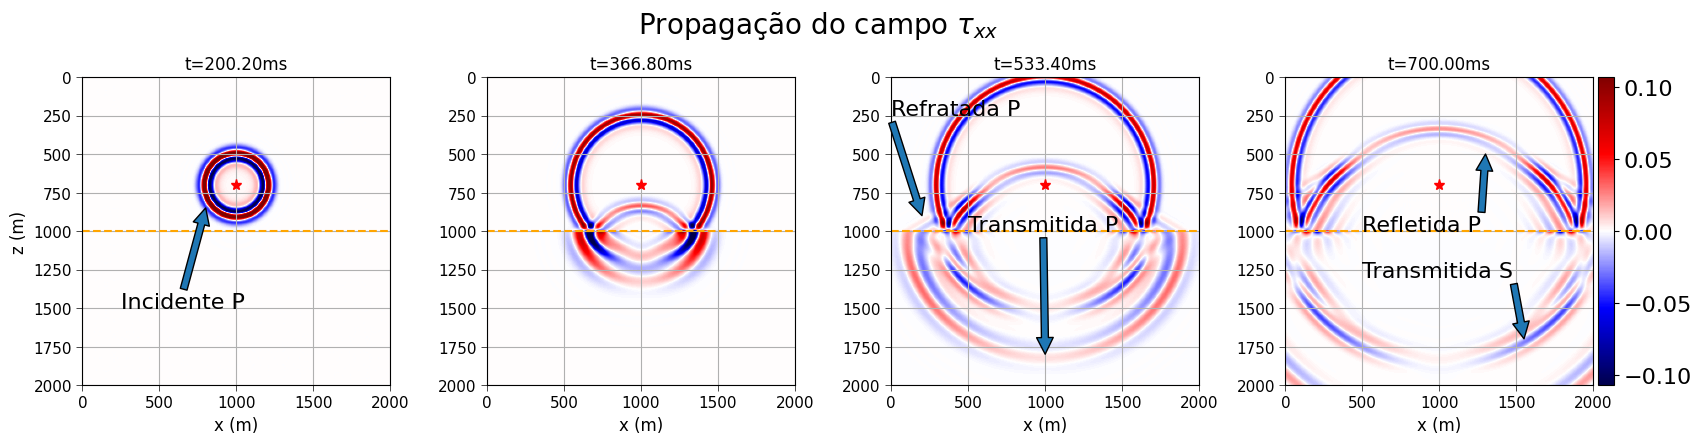

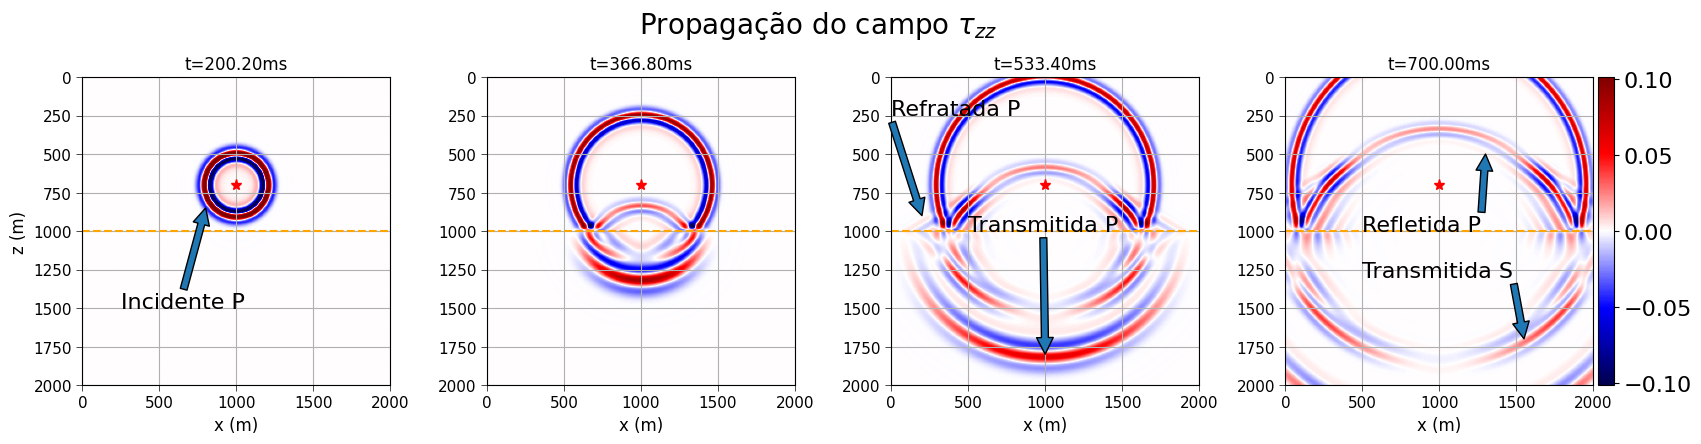

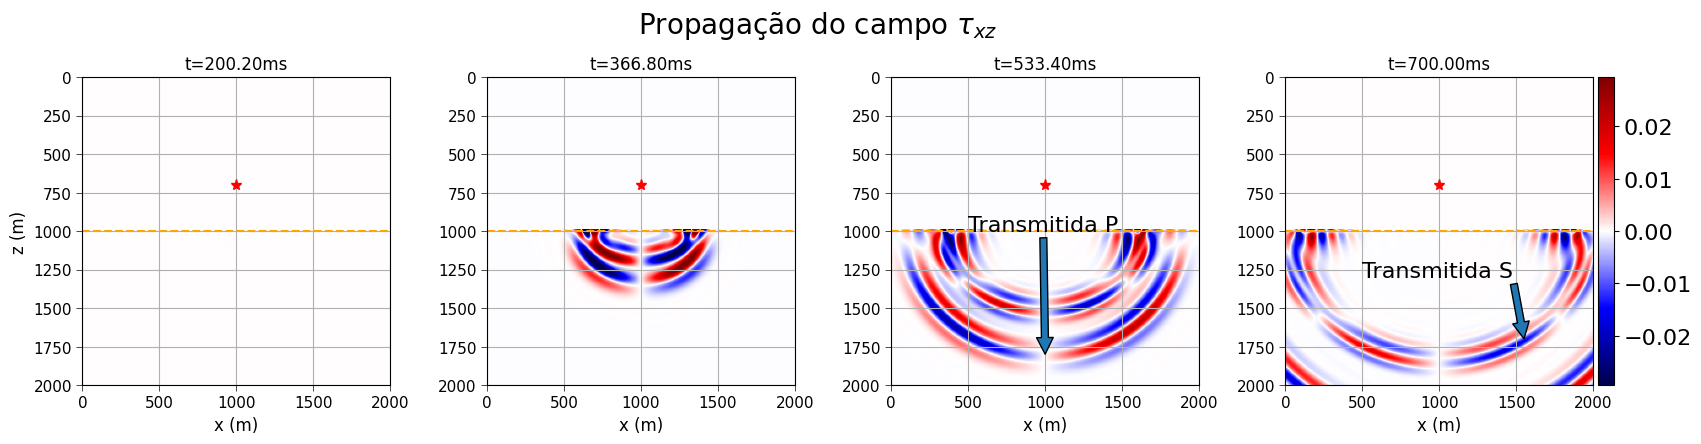

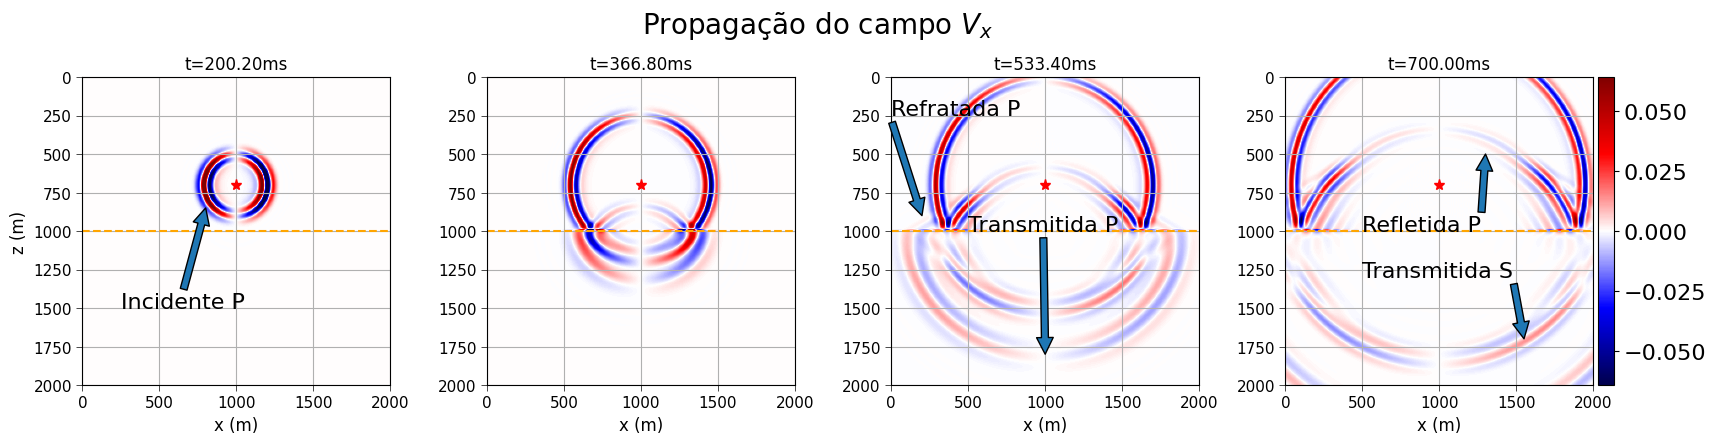

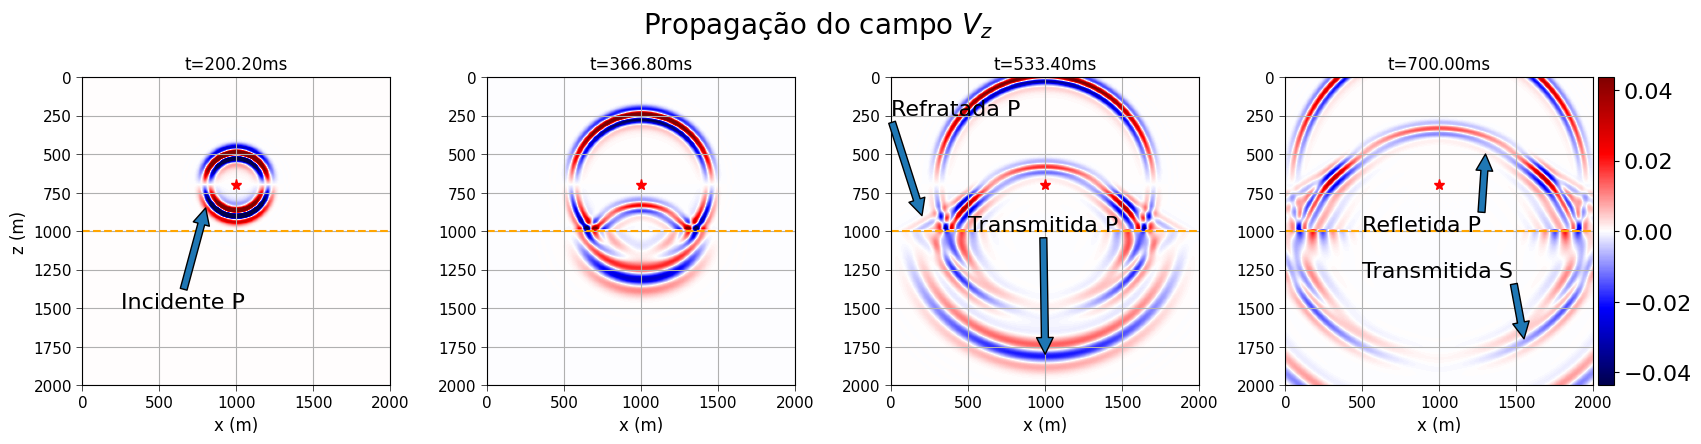

In [23]:
plot_wavefield(tau[0], geometry, src.coordinates.data[0], model, 'Propagação do campo $\\tau_{xx}$', t0=200, tn=700, annotation_callback=annotation_callback_a_1)
plot_wavefield(tau[1], geometry, src.coordinates.data[0], model, 'Propagação do campo $\\tau_{zz}$', t0=200, tn=700, annotation_callback=annotation_callback_a_1)
plot_wavefield(tau[2], geometry, src.coordinates.data[0], model, 'Propagação do campo $\\tau_{xz}$', t0=200, tn=700, annotation_callback=annotation_callback_a_2)

plot_wavefield(v[0], geometry, src.coordinates.data[0], model, 'Propagação do campo $V_x$', t0=200, tn=700, annotation_callback=annotation_callback_a_1)
plot_wavefield(v[1], geometry, src.coordinates.data[0], model, 'Propagação do campo $V_z$', t0=200, tn=700, annotation_callback=annotation_callback_a_1)

## II. Discussão

A onda incidente foi identificada pelo fato de que sua frente de onda se propaga no meio 1 em uma circunferência centrada na fonte.

No meio 1, a onda refletida é uma onda P, pois, como a velocidade $v_{S1}$ do meio 1 é $0$, não há propagação de ondas S.

No meio 2, são transmitidas ondas P e S. A onda P foi identificada pela frente de onda que se propagou mais rápido, e a onda S pela frente de onda que se propagou mais devagar, pois $v_{P2} > v_{S2}$.

A refração foi identificada pela frente de onda no meio que se propaga mais rapidamente através da interface entre os meios.

Não houve difração, pois não há corpos menores que o comprimento da onda propagada.

# Resolução da alternativa b) Interface sólido-sólido

## I. Modelagem, plotagem e ocorrência de eventos

### Parâmetros físicos

As camadas agora possuem os parâmetros:

Camada | $v_P$ ($\mathrm{km/s}$) | $v_S$ ($\mathrm{km/s}$)
-|-|-
1|3.5|2.2
2|2.5|1.8

In [24]:
vp1 = 3.5
vs1 = 2.2
vp2 = 2.5
vs2 = 1.8

model.vp.data[:, :model.nbl + shape[1]//2] = vp1
model.vp.data[:, model.nbl + shape[1]//2:] = vp2

model.vs.data[:, :model.nbl + shape[1]//2] = vs1
model.vs.data[:, model.nbl + shape[1]//2:] = vs2


### Tempo de aquisição

O comprimento do passo temporal deverá satisfazer:
$$
\begin{aligned}
    \Delta t &\le \frac{1}{\max(v_P, v_S)\sqrt{\dfrac{1}{\Delta x^2} + \dfrac{1}{\Delta z^2}}}\\
        &= \frac{1}{3500\ \mathrm{m/s} \sqrt{\dfrac{1}{(8\ \mathrm{m})^2} + \dfrac{1}{(8\ \mathrm{m})^2}}}\\
        &\approx 1.6162\ \mathrm{ms}
\end{aligned}
$$
Com base nisto, o comprimento do passo temporal escolhido foi $\Delta t = 1.0\ \mathrm{ms}$.

In [25]:
dt = 1

op(dt=dt)

PerformanceSummary([(PerfKey(name='section0', rank=None),
                     PerfEntry(time=0.15147000000000013, gflopss=0.0, gpointss=0.0, oi=0.0, ops=0, itershapes=[])),
                    (PerfKey(name='section1', rank=None),
                     PerfEntry(time=4.4999999999999976e-05, gflopss=0.0, gpointss=0.0, oi=0.0, ops=0, itershapes=[]))])

In [26]:
def annotation_callback_b(fig, axes):
    snap200 = axes[0]
    snap266 = axes[1]
    snap333 = axes[2]
    snap500 = axes[3]

    arrowprops={'width': 5}

    snap200.annotate('Incidente P', (500, 750), (0,1750), arrowprops=arrowprops)
    
    # snap333.annotate('Transmitida P', (1000, 1800), (500,1000), arrowprops=arrowprops)

    snap333.annotate('Refletida P', (500, 500), (0,1500), arrowprops=arrowprops)
    snap333.annotate('Refletida S', (1250, 600), (1000,1750), arrowprops=arrowprops)
    
    snap500.annotate('Transmitida P', (600,1600), (0, 2000), arrowprops=arrowprops)
    snap500.annotate('Transmitida S', (1500, 1300), (500,1000), arrowprops=arrowprops)

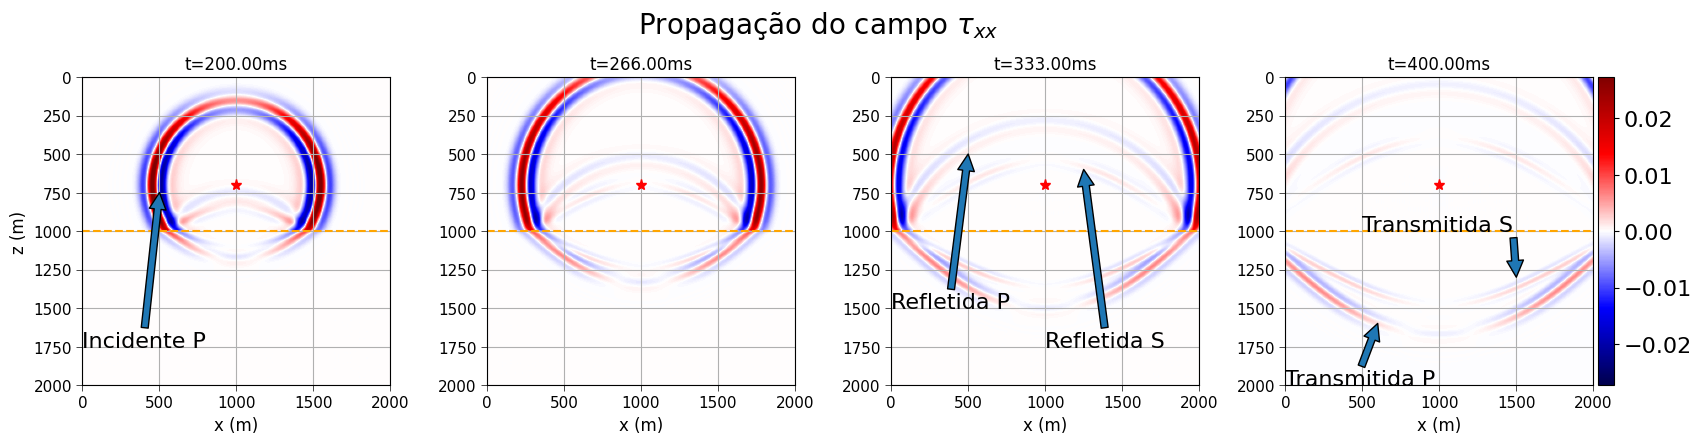

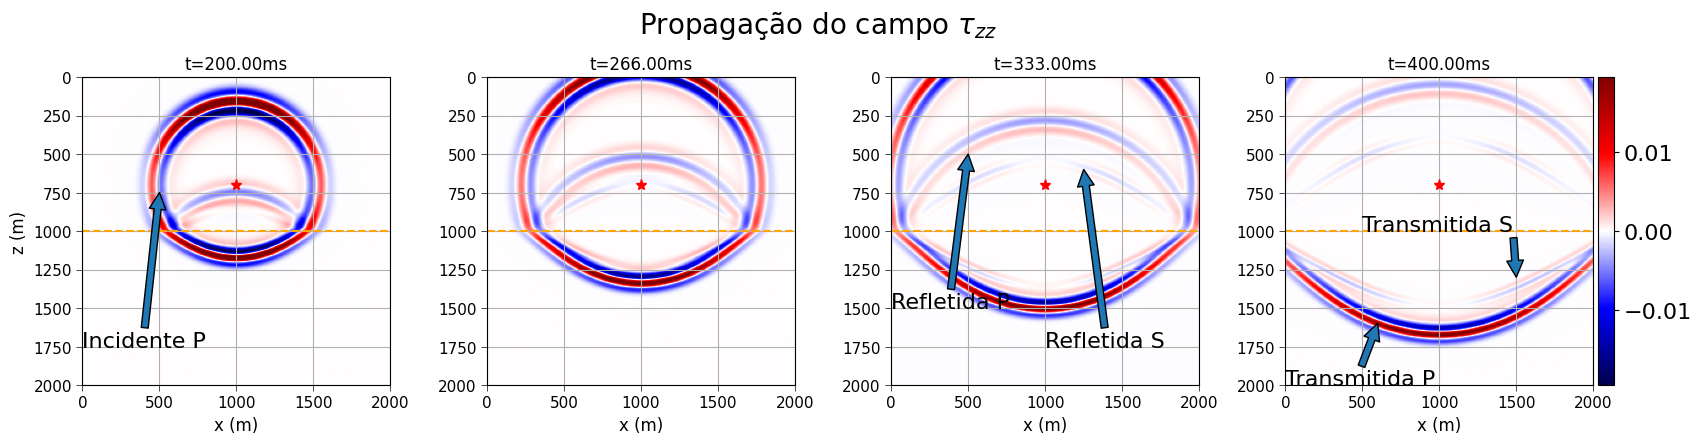

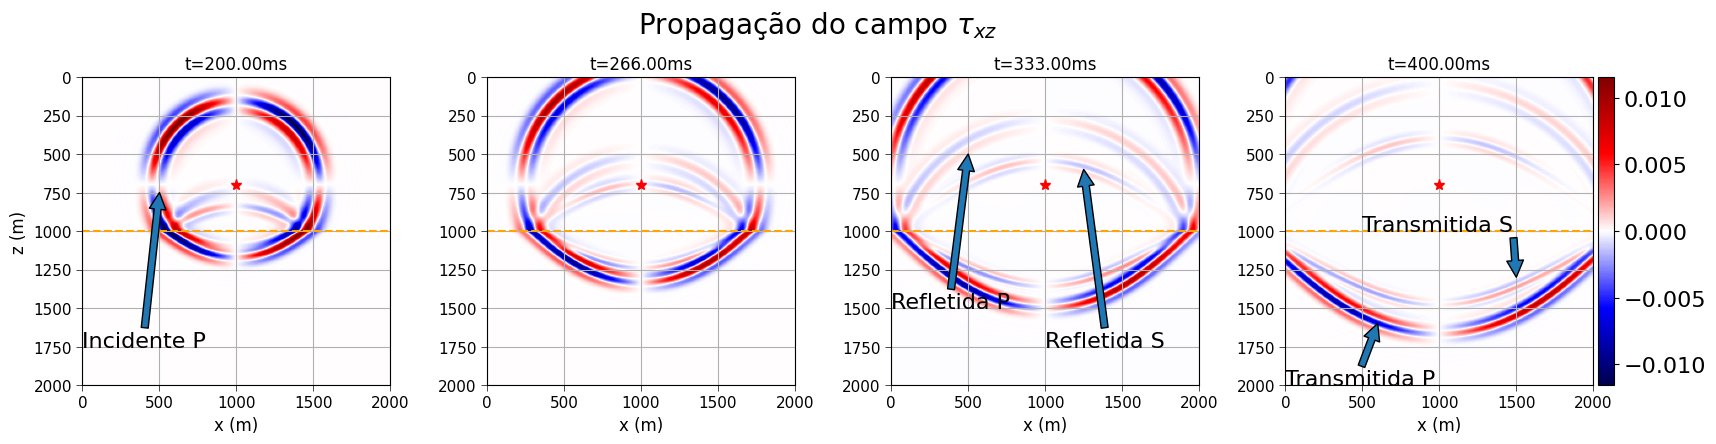

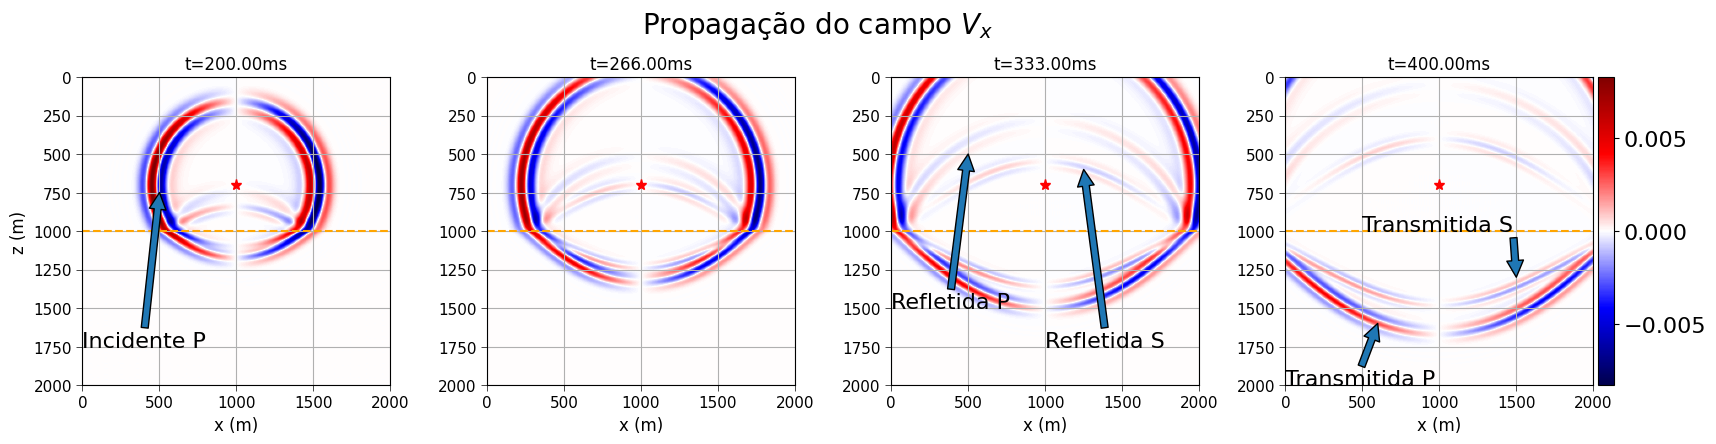

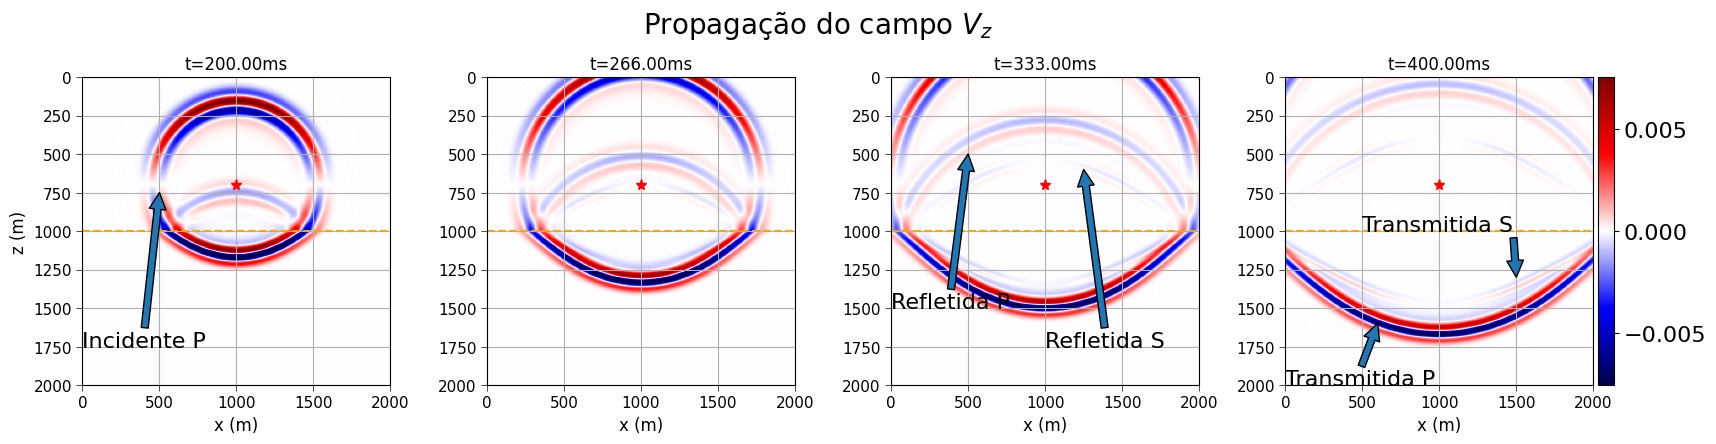

In [27]:
plot_wavefield(tau[0], geometry, src.coordinates.data[0], model, 'Propagação do campo $\\tau_{xx}$', t0=200, tn=400, annotation_callback=annotation_callback_b)
plot_wavefield(tau[1], geometry, src.coordinates.data[0], model, 'Propagação do campo $\\tau_{zz}$', t0=200, tn=400, annotation_callback=annotation_callback_b)
plot_wavefield(tau[2], geometry, src.coordinates.data[0], model, 'Propagação do campo $\\tau_{xz}$', t0=200, tn=400, annotation_callback=annotation_callback_b)

plot_wavefield(v[0], geometry, src.coordinates.data[0], model, 'Propagação do campo $V_x$', t0=200, tn=400, annotation_callback=annotation_callback_b)
plot_wavefield(v[1], geometry, src.coordinates.data[0], model, 'Propagação do campo $V_z$', t0=200, tn=400, annotation_callback=annotation_callback_b)

A onda incidente foi identificada pelo fato de que sua frente de onda se propaga no meio 1 em uma circunferência centrada na fonte.

No meio 1, são refletidas ondas P e S. A onda P foi identificada pela frente de onda que se propagou mais rápido que a da onda S, pois $v_{P1} > v_{S1}$.

No meio 2, são transmitidas ondas P e S. Elas foram identifcadas da mesma forma que o caso anterior.

Não houve refração pois $v_{P1} > v_{P2}$ e $v_{S1} > v_{S2}$, impossibilitando a existência de um ângulo crítico.

Não houve difração, pois não há corpos menores que o comprimento da onda propagada.

## II. Análise de polaridade

# Resolução da alternativa c) Inversão das velocidades das camadas

## I. Modelagem, plotagem e ocorrência de eventos

In [28]:
model.vp.data[:] = np.flip(model.vp.data)
model.vs.data[:] = np.flip(model.vs.data)

In [29]:
op(dt=dt)

PerformanceSummary([(PerfKey(name='section0', rank=None),
                     PerfEntry(time=0.1554500000000004, gflopss=0.0, gpointss=0.0, oi=0.0, ops=0, itershapes=[])),
                    (PerfKey(name='section1', rank=None),
                     PerfEntry(time=4.5999999999999966e-05, gflopss=0.0, gpointss=0.0, oi=0.0, ops=0, itershapes=[]))])

In [30]:
def annotation_callback_c(fig, axes):
    snap200 = axes[0]
    snap266 = axes[1]
    snap333 = axes[2]
    snap500 = axes[3]

    arrowprops={'width': 5}

    snap200.annotate('Incidente P', (600, 760), (0,1500), arrowprops=arrowprops)
    
    # snap333.annotate('Transmitida P', (1000, 1800), (500,1000), arrowprops=arrowprops)

    snap500.annotate('Refletida P', (500, 500), (500,250), arrowprops=arrowprops)
    snap500.annotate('Refletida S', (1250, 650), (500,1250), arrowprops=arrowprops)
    
    snap333.annotate('Transmitida P', (600,1550), (0, 2000), arrowprops=arrowprops)
    snap333.annotate('Transmitida S', (1400, 1200), (500,600), arrowprops=arrowprops)

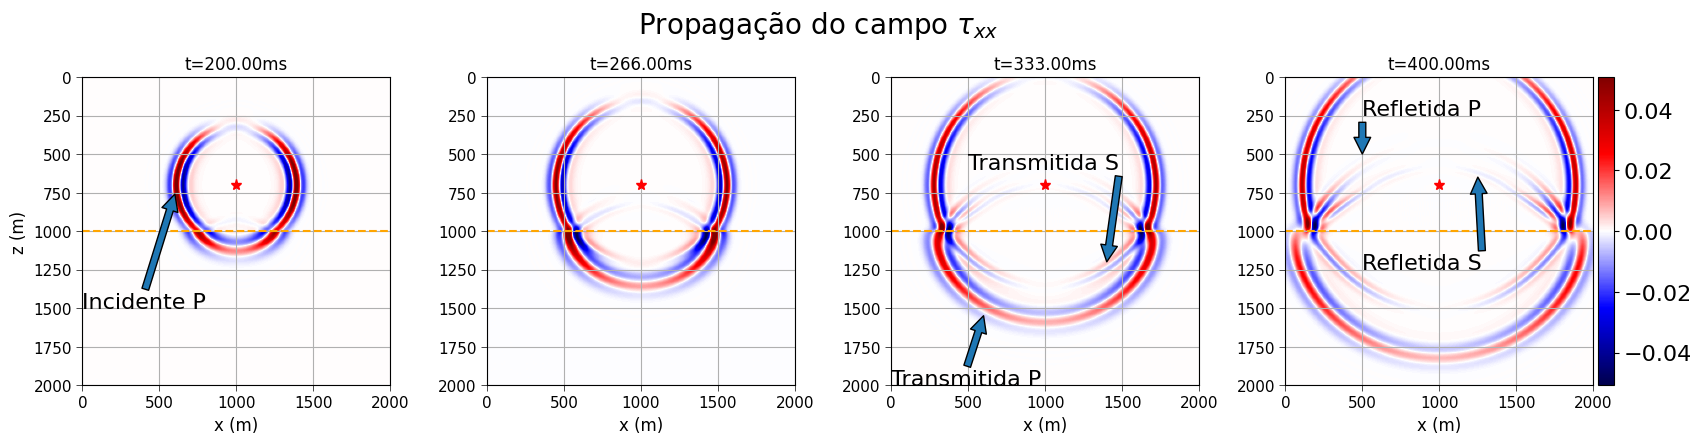

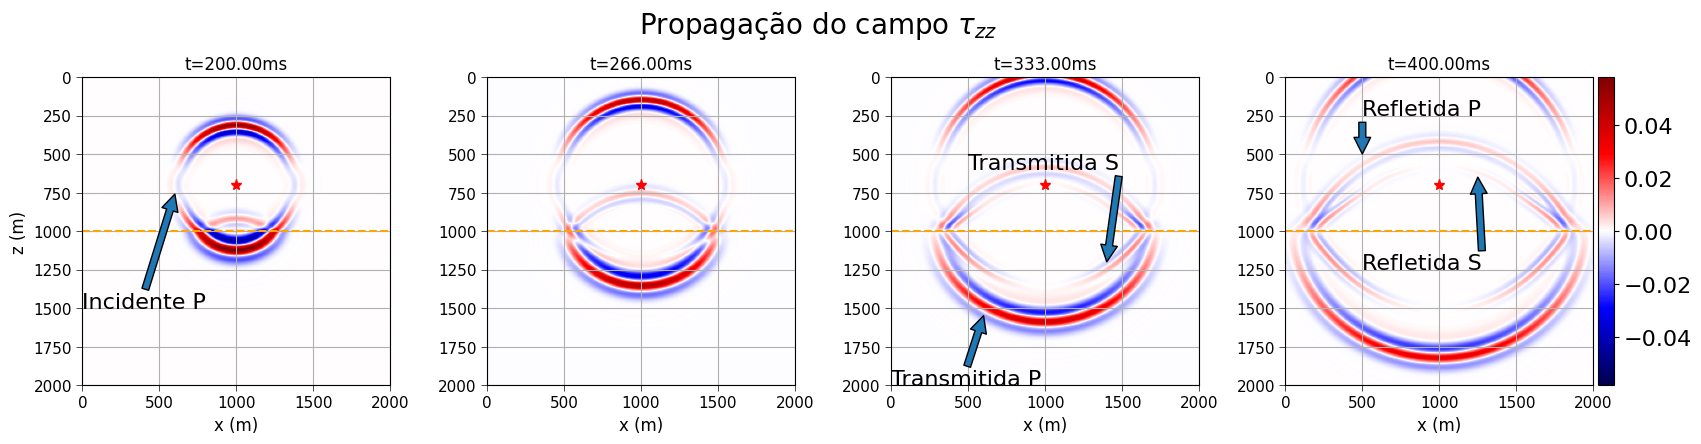

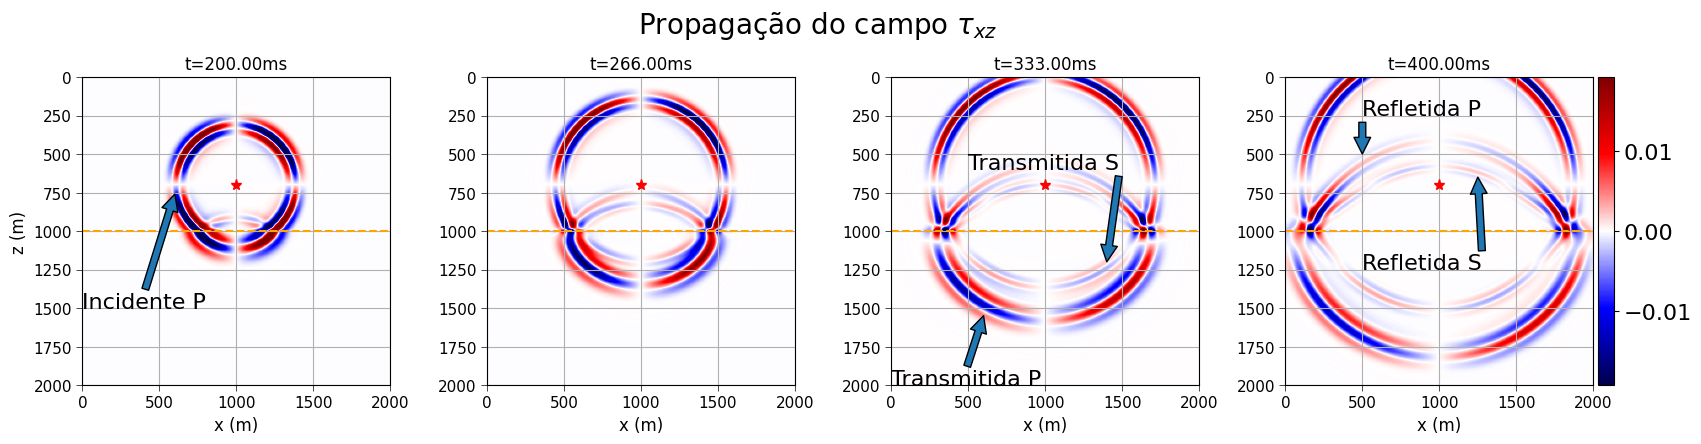

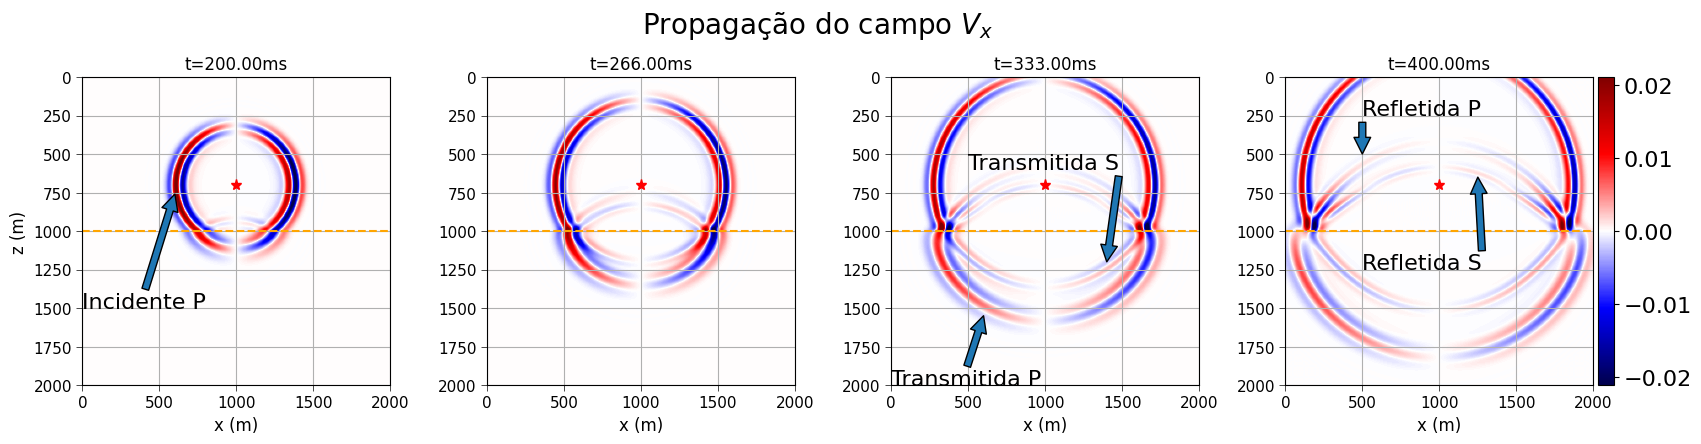

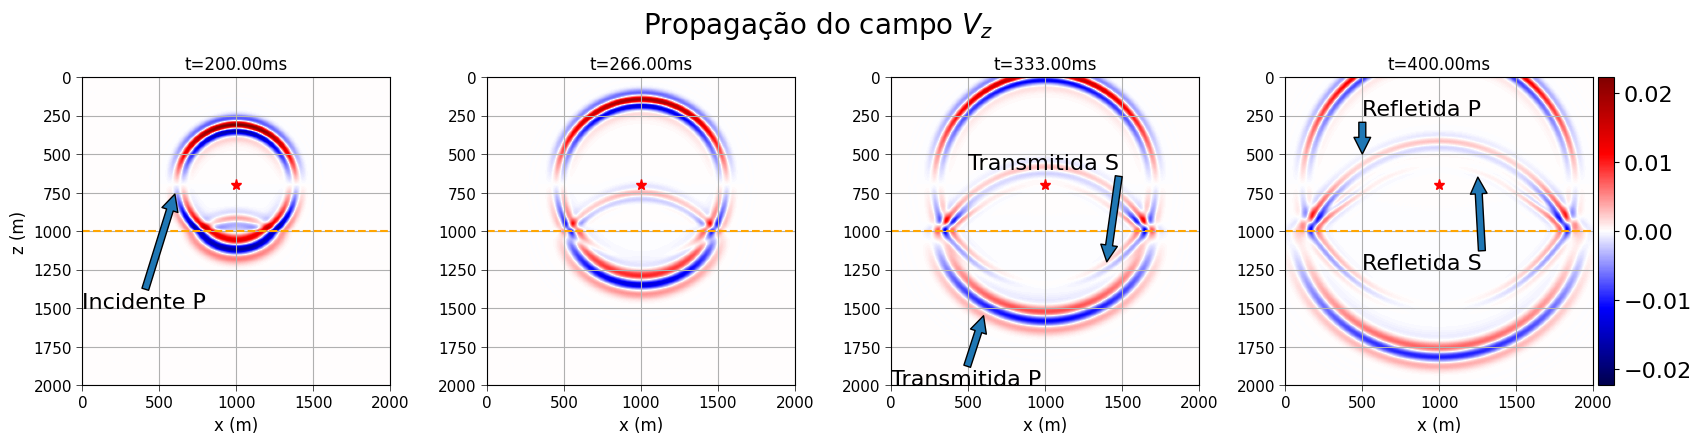

In [31]:
plot_wavefield(tau[0], geometry, src.coordinates.data[0], model, 'Propagação do campo $\\tau_{xx}$', t0=200, tn=400, annotation_callback=annotation_callback_c)
plot_wavefield(tau[1], geometry, src.coordinates.data[0], model, 'Propagação do campo $\\tau_{zz}$', t0=200, tn=400, annotation_callback=annotation_callback_c)
plot_wavefield(tau[2], geometry, src.coordinates.data[0], model, 'Propagação do campo $\\tau_{xz}$', t0=200, tn=400, annotation_callback=annotation_callback_c)

plot_wavefield(v[0], geometry, src.coordinates.data[0], model, 'Propagação do campo $V_x$', t0=200, tn=400, annotation_callback=annotation_callback_c)
plot_wavefield(v[1], geometry, src.coordinates.data[0], model, 'Propagação do campo $V_z$', t0=200, tn=400, annotation_callback=annotation_callback_c)

## II. Análise de polaridade
